In [1]:
import tensorflow as tf

print("Checking Hardware Configuration...\n")

gpus = tf.config.list_physical_devices('GPU')

print("GPUs found:", gpus)

if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("✅ Memory growth enabled")
    except RuntimeError as e:
        print("❌ Error:", e)

I0000 00:00:1777315496.369765  234156 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777315497.700853  234156 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777315538.123422  234156 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Checking Hardware Configuration...

GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Memory growth enabled


In [2]:
# ==============================================================================
# CELL [SETUP]: WSL & GPU CONFIGURATION (WITH XLA/CUDNN BUG FIXES)
# ==============================================================================
import os

# --- XLA & CUDNN COMPILER FIXES FOR WSL ---
# These must be set BEFORE importing tensorflow
# 1. Disable cuDNN autotuning which is crashing the convolution layers
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'
# 2. Tell XLA to ignore missing libdevice and fall back to standard GPU execution
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=0'
# 3. Suppress the annoying warning logs about missing ptxas
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

print("Checking Hardware Configuration on WSL...\n")

# Clear any leftover memory from previous crashed runs
tf.keras.backend.clear_session()

# Check for GPUs
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Enable Memory Growth
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            
        print(f"✅ SUCCESS: {len(gpus)} GPU(s) found and configured natively on WSL!")
        for i, gpu in enumerate(gpus):
            print(f"   - GPU {i}: {gpu.name}")
            
    except RuntimeError as e:
        print(f"❌ GPU Configuration Error: {e}")
else:
    print("❌ WARNING: No GPU detected. Check your WSL CUDA toolkit installation.")

Checking Hardware Configuration on WSL...

✅ SUCCESS: 1 GPU(s) found and configured natively on WSL!
   - GPU 0: /physical_device:GPU:0


In [3]:
# ==============================================================================
# CELL 0: BASE PREPROCESSING & FEATURE EXTRACTION (Run Once)
# ==============================================================================
import os
import glob
import cv2
import pywt
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.model_selection import train_test_split

# --- CONFIGURATION ---
CSV_PATH = 'mass_case_description_train_set.csv'

# Updated WSL Path
BASE_IMAGE_DIR = "/mnt/c/Users/Parat/Desktop/Projects/Spatial model/Main/Images"
IMAGE_SIZE = (224, 224)

def extract_features(img):
    features = []
    
    # 1. Histogram Features
    features.extend([np.mean(img), np.std(img)])
    
    # 2. Texture Features - LBP
    radius = 3
    n_points = 8 * radius
    lbp = local_binary_pattern(img, n_points, radius, method='uniform')
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    hist = hist.astype("float") / (hist.sum() + 1e-6)
    features.extend(hist)
    
    # 3. Texture Features - GLCM
    glcm = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    features.append(graycoprops(glcm, 'contrast')[0, 0])
    features.append(graycoprops(glcm, 'homogeneity')[0, 0])
    features.append(graycoprops(glcm, 'energy')[0, 0])
    features.append(graycoprops(glcm, 'correlation')[0, 0])
    
    # 4. Wavelet Features
    coeffs = pywt.dwt2(img, 'haar')
    cA, (cH, cV, cD) = coeffs
    features.extend([np.mean(cA), np.std(cA), np.mean(cH), np.std(cH), 
                     np.mean(cV), np.std(cV), np.mean(cD), np.std(cD)])
                     
    # 5. Shape Features (Basic contour simulation)
    _, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        features.extend([cv2.contourArea(c), cv2.arcLength(c, True)])
    else:
        features.extend([0, 0])
        
    return np.array(features)

print("Loading dataset and extracting features (CPU)...")
df = pd.read_csv(CSV_PATH)

X, y = [], []

for index, row in df.iterrows():
    pathology = str(row['pathology'])
    label = 1 if 'MALIGNANT' in pathology else 0
    
    parts = str(row['image file path']).split('/')
    if len(parts) >= 3:
        folder_name = parts[2]
    else:
        continue
        
    search_pattern = os.path.join(BASE_IMAGE_DIR, '**', folder_name, '1-*.jpg')
    img_files = glob.glob(search_pattern, recursive=True)
    
    if len(img_files) > 0:
        img = cv2.imread(img_files[0], cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, IMAGE_SIZE)
            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
            
            feats = extract_features(img)
            X.append(feats)
            y.append(label)

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"✅ Feature extraction complete! Extracted {X.shape[1]} features from {X.shape[0]} images.")

Loading dataset and extracting features (CPU)...
✅ Feature extraction complete! Extracted 42 features from 1318 images.


Training SVM...
SVM Accuracy: 0.6553 | AUC-ROC: 0.6615


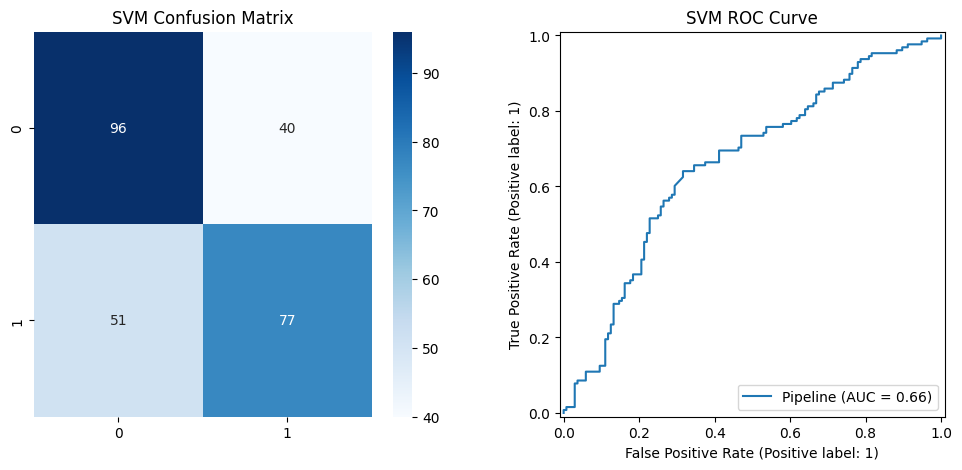

In [4]:
# ==============================================================================
# CELL 1: SUPPORT VECTOR MACHINE (SVM)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)), 
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])

print("Training SVM...")
svm_pipeline.fit(X_train, y_train)

y_pred = svm_pipeline.predict(X_test)
y_prob = svm_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
print(f"SVM Accuracy: {acc:.4f} | AUC-ROC: {auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('SVM Confusion Matrix')
RocCurveDisplay.from_estimator(svm_pipeline, X_test, y_test, ax=axes[1])
axes[1].set_title('SVM ROC Curve')
plt.show()

Training Random Forest...
Random Forest Accuracy: 0.6439 | AUC-ROC: 0.7121


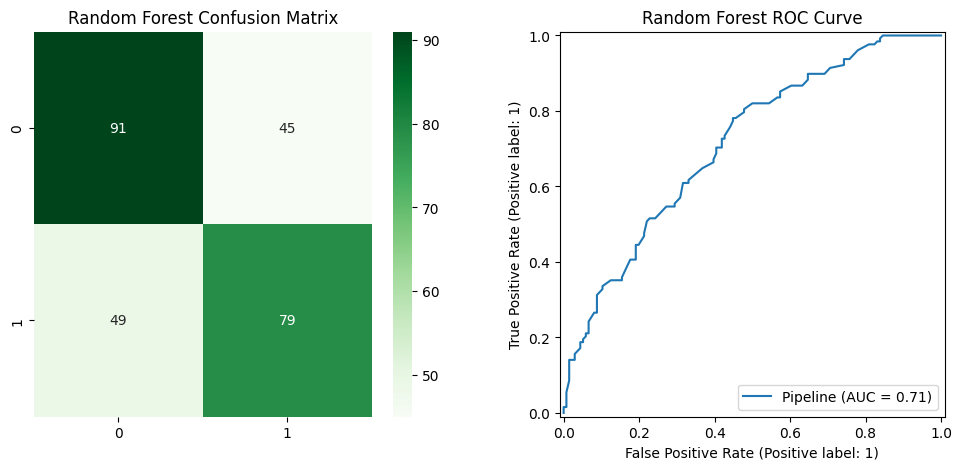

In [5]:
# ==============================================================================
# CELL 2: RANDOM FOREST CLASSIFIER
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
print(f"Random Forest Accuracy: {acc:.4f} | AUC-ROC: {auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title('Random Forest Confusion Matrix')
RocCurveDisplay.from_estimator(rf_pipeline, X_test, y_test, ax=axes[1])
axes[1].set_title('Random Forest ROC Curve')
plt.show()

Training XGBoost on GPU...
XGBoost Accuracy: 0.6742 | AUC-ROC: 0.7278


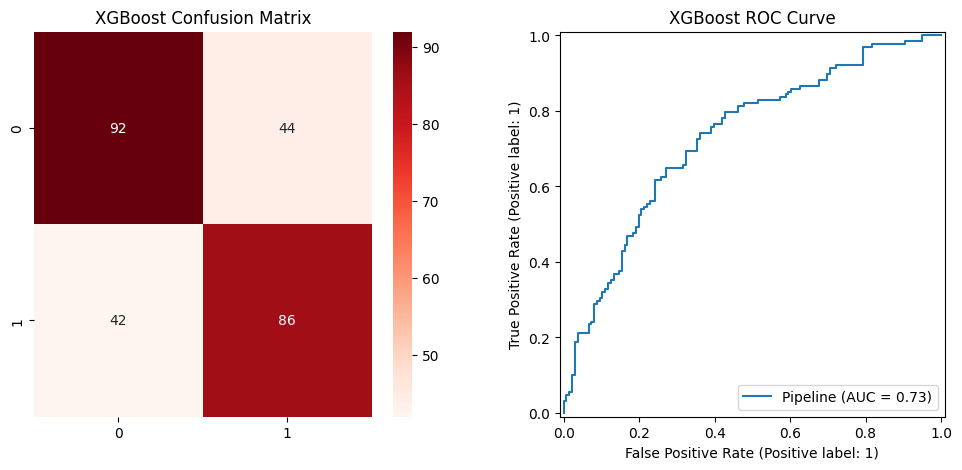

In [6]:
# ==============================================================================
# CELL 3: XGBOOST (GPU ACCELERATED)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('xgb', xgb.XGBClassifier(
        tree_method='hist', 
        device='cuda',        # Activates GPU in XGBoost
        use_label_encoder=False, 
        eval_metric='logloss', 
        random_state=42
    ))
])

print("Training XGBoost on GPU...")
try:
    xgb_pipeline.fit(X_train, y_train)
except Exception as e:
    print(f"GPU failed, falling back to CPU. Error: {e}")
    xgb_pipeline.set_params(xgb__device='cpu')
    xgb_pipeline.fit(X_train, y_train)

y_pred = xgb_pipeline.predict(X_test)
y_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
print(f"XGBoost Accuracy: {acc:.4f} | AUC-ROC: {auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', ax=axes[0])
axes[0].set_title('XGBoost Confusion Matrix')
RocCurveDisplay.from_estimator(xgb_pipeline, X_test, y_test, ax=axes[1])
axes[1].set_title('XGBoost ROC Curve')
plt.show()

Training KNN...
KNN Accuracy: 0.5455 | AUC-ROC: 0.5822


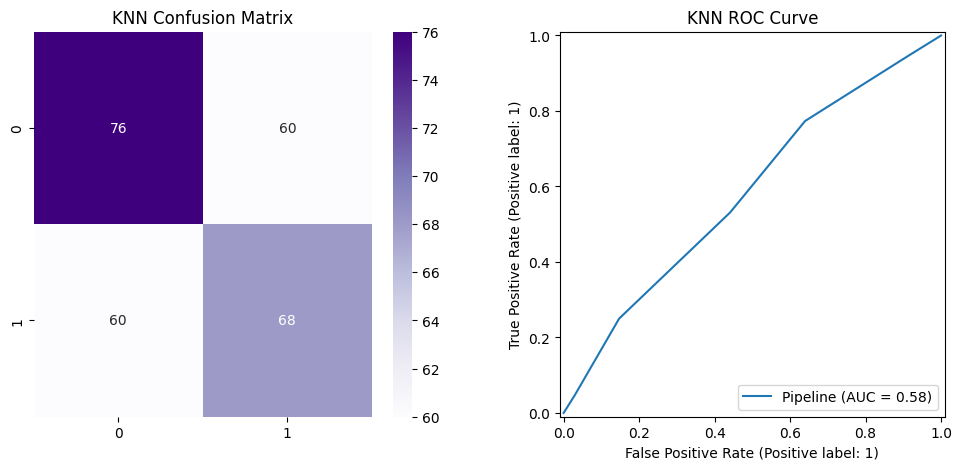

In [7]:
# ==============================================================================
# CELL 4: K-NEAREST NEIGHBORS (KNN)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

print("Training KNN...")
knn_pipeline.fit(X_train, y_train)

y_pred = knn_pipeline.predict(X_test)
y_prob = knn_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
print(f"KNN Accuracy: {acc:.4f} | AUC-ROC: {auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples', ax=axes[0])
axes[0].set_title('KNN Confusion Matrix')
RocCurveDisplay.from_estimator(knn_pipeline, X_test, y_test, ax=axes[1])
axes[1].set_title('KNN ROC Curve')
plt.show()

Training Naive Bayes...
Naive Bayes Accuracy: 0.5455 | AUC-ROC: 0.5823


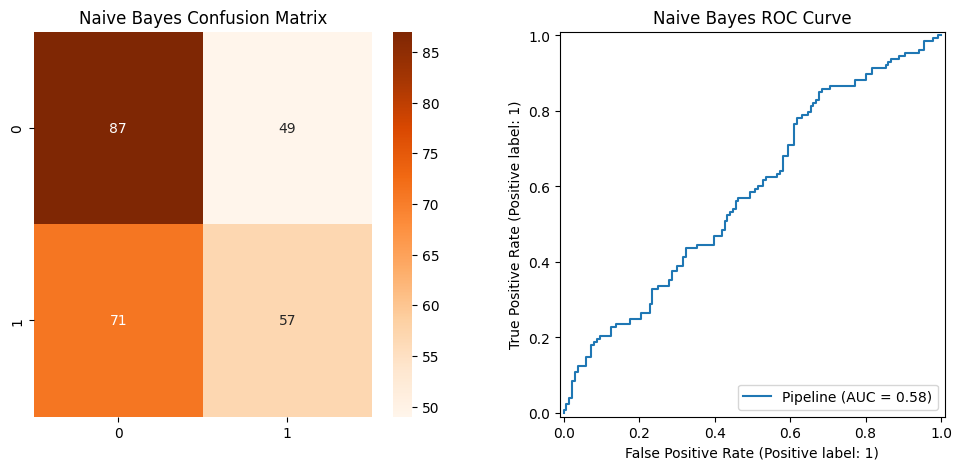

In [8]:
# ==============================================================================
# CELL 5: NAIVE BAYES
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay

nb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('nb', GaussianNB())
])

print("Training Naive Bayes...")
nb_pipeline.fit(X_train, y_train)

y_pred = nb_pipeline.predict(X_test)
y_prob = nb_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
print(f"Naive Bayes Accuracy: {acc:.4f} | AUC-ROC: {auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges', ax=axes[0])
axes[0].set_title('Naive Bayes Confusion Matrix')
RocCurveDisplay.from_estimator(nb_pipeline, X_test, y_test, ax=axes[1])
axes[1].set_title('Naive Bayes ROC Curve')
plt.show()

In [9]:
# ==============================================================================
# CELL 6: DEEP LEARNING (DenseNet121 Transfer Learning - GPU Accelerated)
# ==============================================================================
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

# --- CONFIGURATION ---
CSV_PATH = 'mass_case_description_train_set.csv'
BASE_IMAGE_DIR = "/mnt/c/Users/Parat/Desktop/Projects/Spatial model/Main/Images"

print("Mapping images...")
df = pd.read_csv(CSV_PATH)

image_paths, labels = [], []

# 1. Image Mapping
for index, row in df.iterrows():
    pathology = str(row['pathology'])
    label = 'MALIGNANT' if 'MALIGNANT' in pathology else 'BENIGN'
    
    parts = str(row['image file path']).split('/')
    if len(parts) >= 3:
        folder_name = parts[2]
    else:
        continue
        
    search_pattern = os.path.join(BASE_IMAGE_DIR, '**', folder_name, '1-*.jpg')
    img_files = glob.glob(search_pattern, recursive=True)
    
    if len(img_files) > 0:
        image_paths.append(img_files[0])
        labels.append(label)

data_df = pd.DataFrame({'filename': image_paths, 'class': labels})
print(f"✅ SUCCESS: Mapped {len(data_df)} images for DenseNet!")

if len(data_df) == 0:
    raise ValueError("0 images mapped. Check your BASE_IMAGE_DIR path or casing.")

# 2. Data Generators (Batch size 8 prevents GPU OOM)
BATCH_SIZE = 8
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_dataframe(
    data_df, x_col='filename', y_col='class', target_size=(224, 224), 
    batch_size=BATCH_SIZE, class_mode='binary', subset='training'
)
val_gen = datagen.flow_from_dataframe(
    data_df, x_col='filename', y_col='class', target_size=(224, 224), 
    batch_size=BATCH_SIZE, class_mode='binary', subset='validation', shuffle=False
)

# 3. DenseNet Model Setup
print("Building DenseNet121 Model...")
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy', metrics=['accuracy'])

# 4. Train Model
print("Training Deep Neural Network on GPU...")
history = model.fit(train_gen, validation_data=val_gen, epochs=10)

# 5. Predictions & Evaluation
print("Evaluating Model...")
y_true = val_gen.classes
y_prob = model.predict(val_gen).ravel()
y_pred = (y_prob > 0.5).astype(int)

acc = accuracy_score(y_true, y_pred)
roc_auc = auc(*roc_curve(y_true, y_prob)[:2])
print(f"DenseNet Accuracy: {acc:.4f} | AUC: {roc_auc:.4f}")

# 6. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('DenseNet Confusion Matrix')

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('DenseNet ROC Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

Mapping images...
✅ SUCCESS: Mapped 1318 images for DenseNet!
Found 1055 validated image filenames belonging to 2 classes.
Found 263 validated image filenames belonging to 2 classes.
Building DenseNet121 Model...


I0000 00:00:1777366890.047209  234156 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5546 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
W0000 00:00:1777366890.942571  383098 nvptx_libdevice_path.cc:41] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./cuda_sdk_lib
  ipykernel_launcher.runfiles/cuda_nvcc
  ipykernel_launcher.runfiles/cuda_nvdisasm
  ipykernel_launcher.runfiles/nvidia_nvshmem
  ipykernel_launcher.runfiles/cuda_nvvm
  ipykernel_launcher.runfiles/cuda_cudart
  /usr/local/cuda
  /opt/cuda
  /mnt/c/Users/Parat/Desktop/Projects/Spatial model/Main/tf-gpu/lib/python3.10/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /mnt/c/Users/Parat/Desktop/Projects/Spatial model/Main/tf-gpu/li

Training Deep Neural Network on GPU...
Epoch 1/10


I0000 00:00:1777366896.470514  234156 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1777366903.219775  383091 service.cc:153] XLA service 0x72af7c03c1f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777366903.219840  383091 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.3.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777366903.608889  383091 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777366906.111802  383091 cuda_dnn.cc:461] Loaded cuDNN version 92101
W0000 00:00:1777366907.585370  383091 op_kernel.cc:1858] OP_REQUIRES failed at xla_ops.cc:602 : INTERNAL: Autotuner could not compile any configs for HLO: %cudnn-conv.185 = (f32[8,128,14,14]{3,2,1,0}, u8[0]{0}) custom-call(%maximum.67, %transpose.71), window={size=1x1}, dim_la

InternalError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main

  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code

  File "/mnt/c/Users/Parat/Desktop/Projects/Spatial model/Main/tf-gpu/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/mnt/c/Users/Parat/Desktop/Projects/Spatial model/Main/tf-gpu/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/mnt/c/Users/Parat/Desktop/Projects/Spatial model/Main/tf-gpu/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/mnt/c/Users/Parat/Desktop/Projects/Spatial model/Main/tf-gpu/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.10/asyncio/base_events.py", line 603, in run_forever

  File "/usr/lib/python3.10/asyncio/base_events.py", line 1909, in _

In [10]:
import numpy as np
# Run this immediately if your variables are still in memory!
np.savez_compressed('extracted_features.npz', 
                    X_train=X_train, X_test=X_test, 
                    y_train=y_train, y_test=y_test)
print("✅ Saved! Your 7 hours of work is safely on your hard drive.")

✅ Saved! Your 7 hours of work is safely on your hard drive.
